In [5]:

import pandas as pd

df = pd.read_csv('BDD_Billboard_copia_Limpia_2000.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'] = df['date'].dt.year

df = df.drop(columns=['image_url', 'rank', 'weeks_in_charts', 'last_week'])

# Renombrar columnas
df = df.rename(columns={
    'date': 'Año',
    'song': 'Canción',
    'artist': 'Artista',
    'peak_position': 'Máxima_posición'
})

# Columna 'Canción' ya renombrada
df = df.drop(columns=['Canción'])
df_filtered = df[(df['Máxima_posición'] >= 1) & (df['Máxima_posición'] <= 10)]
df_small = df_filtered[df_filtered['Año'].between(2000, 2010)]


df.head()




,Año,Artista,Máxima_posición
0,2000,Santana Featuring Rob Thomas,1
1,2000,Brian McKnight,2
2,2000,Jessica Simpson,3
3,2000,Whitney Houston,4
4,2000,"Missy ""Misdemeanor"" Elliott Featuring NAS| EVE...",5


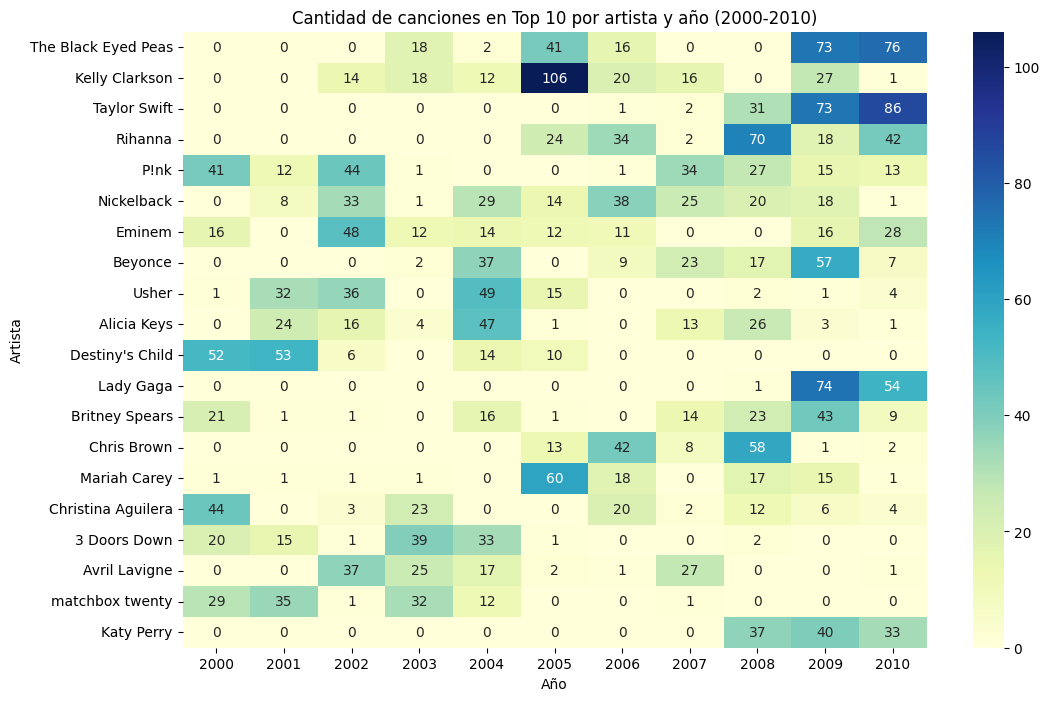

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('BDD_Billboard_copia_Limpia_2000.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'] = df['date'].dt.year

df = df.drop(columns=['image_url', 'rank', 'weeks_in_charts', 'last_week'])

df = df.rename(columns={
    'date': 'Año',
    'song': 'Canción',
    'artist': 'Artista',
    'peak_position': 'Máxima_posición'
})

df = df.drop(columns=['Canción'])
df_filtered = df[(df['Máxima_posición'] >= 1) & (df['Máxima_posición'] <= 10)]
df_small = df_filtered[df_filtered['Año'].between(2000, 2010)]


pivot_table = df_small.pivot_table(
    index='Artista',
    columns='Año',
    values='Máxima_posición',
    aggfunc='count',
    fill_value=0
)

# Artistas con más canciones
top_artistas = pivot_table.sum(axis=1).sort_values(ascending=False).head(20).index
pivot_table_top = pivot_table.loc[top_artistas]

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table_top, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Cantidad de canciones en Top 10 por artista y año (2000-2010)')
plt.ylabel('Artista')
plt.xlabel('Año')

plt.show()

In [16]:
import pandas as pd
import altair as alt

# Asumo que pivot_table_top ya está generado para 2000-2010, si no, genera así:
# pivot_table_top = ...

# Transformar pivot para Altair (de wide a long)
df_long = pivot_table_top.reset_index().melt(id_vars='Artista', var_name='Año', value_name='Cantidad')

# Convertir Año a string para mejor manejo en Altair
df_long['Año'] = df_long['Año'].astype(str)

# Crear selección para zoom y pan (intervalo)
brush = alt.selection_interval(encodings=['x', 'y'])

# Crear selección para resaltar fila o columna (clic)
highlight = alt.selection_single(fields=['Artista'], empty='none')

# Heatmap base azul
heatmap = alt.Chart(df_long).mark_rect().encode(
    x=alt.X('Año:O', title='Año'),  # ordinal para eje x
    y=alt.Y('Artista:O', title='Artista', sort=alt.EncodingSortField(field='Cantidad', order='descending')),
    color=alt.Color('Cantidad:Q', scale=alt.Scale(scheme='blues'), title='Cantidad de canciones'),
    tooltip=['Artista', 'Año', 'Cantidad']
).properties(
    width=700,
    height=500,
    title='Cantidad de canciones en top 10 por artistas año (2000-2010)'
).add_selection(
    brush,      # para zoom y pan
    highlight   # para seleccionar artista con click
).transform_filter(
    brush       # filtra solo la parte seleccionada por zoom
)

# Texto que se muestra cuando haces click para resaltar artista
text = alt.Chart(df_long).mark_text(
    align='left',
    baseline='middle',
    dx=5,
    dy=-5,
    fontWeight='bold',
    color='black'
).encode(
    x='Año:O',
    y='Artista:O',
    text=alt.condition(highlight, 'Cantidad:Q', alt.value('')),
).add_selection(
    highlight
)

# Mostrar heatmap + texto (resaltado)
chart = heatmap + text

chart.show()

/tmp/ipython-input-355374362.py:17: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use selection_point instead.

/tmp/ipython-input-355374362.py:29: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.

/tmp/ipython-input-355374362.py:48: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.



alt.LayerChart(...)

In [9]:
import pandas as pd


df = pd.read_csv('BDD_Billboard_copia_Limpia_2000.csv')

# Convertir columna 'date' a datetime y extraer solo el año
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'] = df['date'].dt.year

# Eliminar columnas
df = df.drop(columns=['image_url', 'rank', 'weeks_in_charts', 'last_week'])


df = df.rename(columns={
    'date': 'Año',
    'song': 'Canción',
    'artist': 'Artista',
    'peak_position': 'Máxima_posición'
})

# Eliminar la columna 'Canción'
df = df.drop(columns=['Canción'])

# Filtrar para máximo posición entre 1 y 10
df_filtered = df[(df['Máxima_posición'] >= 1) & (df['Máxima_posición'] <= 10)]

# Dividir en dos dataframes por rangos de años
df_2000_2010 = df_filtered[df_filtered['Año'].between(2000, 2010)]
df_2011_2025 = df_filtered[df_filtered['Año'].between(2011, 2025)]


print("\nDatos 2011-2025:")
print(df_2011_2025.head())


Datos 2011-2025:
        Año                  Artista  Máxima_posición
57400  2011               Bruno Mars                1
57401  2011               Katy Perry                1
57402  2011                    Ke$ha                1
57403  2011  Rihanna Featuring Drake                1
57404  2011                     P!nk                1


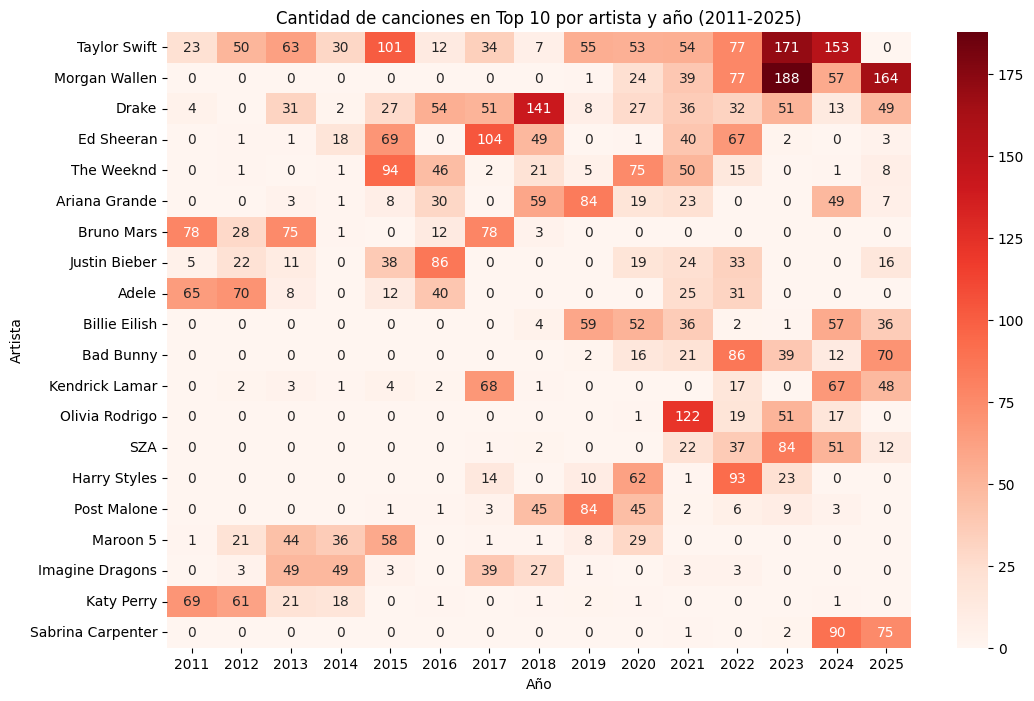

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('BDD_Billboard_copia_Limpia_2000.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'] = df['date'].dt.year

df = df.drop(columns=['image_url', 'rank', 'weeks_in_charts', 'last_week'])

df = df.rename(columns={
    'date': 'Año',
    'song': 'Canción',
    'artist': 'Artista',
    'peak_position': 'Máxima_posición'
})

df = df.drop(columns=['Canción'])
df_filtered = df[(df['Máxima_posición'] >= 1) & (df['Máxima_posición'] <= 10)]


df_small_2011_2025 = df_filtered[df_filtered['Año'].between(2011, 2025)]

pivot_table = df_small_2011_2025.pivot_table(
    index='Artista',
    columns='Año',
    values='Máxima_posición',
    aggfunc='count',
    fill_value=0
)

# artistas con más canciones
top_artistas = pivot_table.sum(axis=1).sort_values(ascending=False).head(20).index
pivot_table_top = pivot_table.loc[top_artistas]

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table_top, annot=True, fmt='d', cmap='Reds')

plt.title('Cantidad de canciones en Top 10 por artista y año (2011-2025)')
plt.ylabel('Artista')
plt.xlabel('Año')

plt.show()

In [14]:
import pandas as pd
import altair as alt

# Preparar tus datos: suponiendo que pivot_table_top ya está listo
# Primero transformamos el pivot para Altair (de wide a long)
df_long = pivot_table_top.reset_index().melt(id_vars='Artista', var_name='Año', value_name='Cantidad')

# Convertir Año a string para mejor manejo en Altair
df_long['Año'] = df_long['Año'].astype(str)

# Crear selección para zoom y pan (intervalo)
brush = alt.selection_interval(encodings=['x', 'y'])

# Crear selección para resaltar fila o columna (clic)
highlight = alt.selection_single(fields=['Artista'], empty='none')

# Heatmap base
heatmap = alt.Chart(df_long).mark_rect().encode(
    x=alt.X('Año:O', title='Año'),  # ordinal para eje x
    y=alt.Y('Artista:O', title='Artista', sort=alt.EncodingSortField(field='Cantidad', order='descending')),
    color=alt.Color('Cantidad:Q', scale=alt.Scale(scheme='reds'), title='Cantidad de canciones'),
    tooltip=['Artista', 'Año', 'Cantidad']
).properties(
    width=700,
    height=500,
    title='Cantidad de canciones en top 10 por artistas año (2011-2025)'
).add_selection(
    brush,      # para zoom y pan
    highlight   # para seleccionar artista con click
).transform_filter(
    brush       # filtra solo la parte seleccionada por zoom
)

# Texto que se muestra cuando haces click para resaltar artista
text = alt.Chart(df_long).mark_text(
    align='left',
    baseline='middle',
    dx=5,
    dy=-5,
    fontWeight='bold',
    color='black'
).encode(
    x='Año:O',
    y='Artista:O',
    text=alt.condition(highlight, 'Cantidad:Q', alt.value('')),
).add_selection(
    highlight
)

# Mostrar heatmap + texto (resaltado)
chart = heatmap + text

chart.show()

/tmp/ipython-input-3144553775.py:15: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use selection_point instead.

/tmp/ipython-input-3144553775.py:27: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.

/tmp/ipython-input-3144553775.py:46: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.



alt.LayerChart(...)